In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk
import batman
import emcee
import seaborn as sns

# Configuração para gráficos bonitos no notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)

c:\Users\denilson\Desktop\ml-data\probabilidade\venv\Lib\site-packages\lightkurve\search.py:421: LightkurveWarning: Warning: 3 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


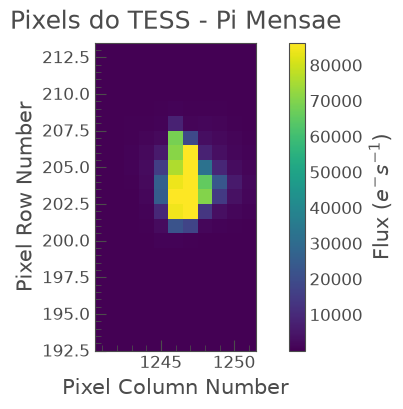

In [9]:
# 1. Defina o alvo que você quer estudar
alvo = "Pi Mensae" # Você pode trocar por "KIC 8462852" ou qualquer outro alvo que esteja no catálogo TESS ou Kepler.
setor = 27 # Coloque None se quiser o primeiro que aparecer

search_result = lk.search_targetpixelfile(alvo, mission='TESS', sector=setor)

if search_result == None or len(search_result) == 0:
    raise ValueError(f"Nenhum resultado encontrado para o alvo {alvo} no setor {setor}.")


tpf = search_result.download(quality_bitmask='default')

tpf.plot(title=f"Pixels do TESS - {alvo}")
plt.show()

# demorou muito

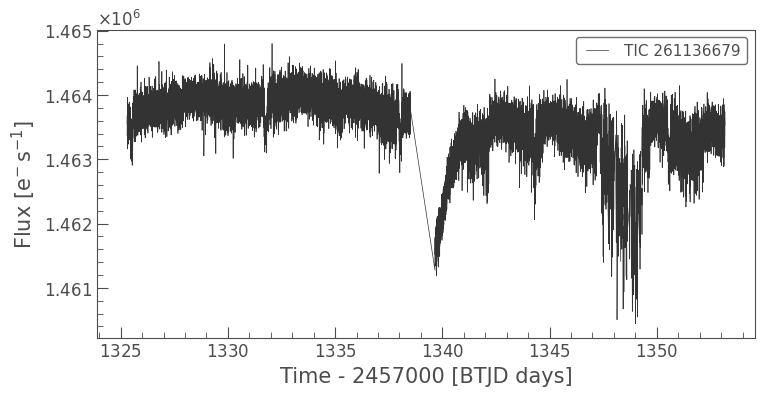

In [ ]:
# apliciar uma mascara e corrigir a curva de luz
# a máscara pode ser criada com base em um limiar de desvio padrão dos valores de fluxo
# ou desenhada manualmente
# ou usando uma máscara pré-definida (pipeline mask)
# ou usando uma máscara manual (você desenha uma forma, como um círculo ou polígono, selecionando pixels "à mão")
# ou usando uma máscara de threshold (limiar) de desvio padrão dos valores de fluxo
mask = pixelfile.create_threshold_mask(threshold=3)
# o pld (PLDCorrector) é um corretor de curva de luz que usa o método de correção de polinômios locais
# ele corrige a curva de luz usando uma máscara de pixels
# o método PLDCorrector é usado para corrigir a curva de luz usando polinômios locais
# o método correct() retorna a curva de luz corrigida
pld = PLDCorrector(pixelfile, aperture_mask=mask)
lc = pld.correct()
lc.scatter(title="Curva de Luz Corrigida Espacialmente (PLD)", alpha=0.5)
plt.show()

In [ ]:
#remocao de intervalos vazios
lc = lc.remove_nans()
lc.plot()
lc.show()

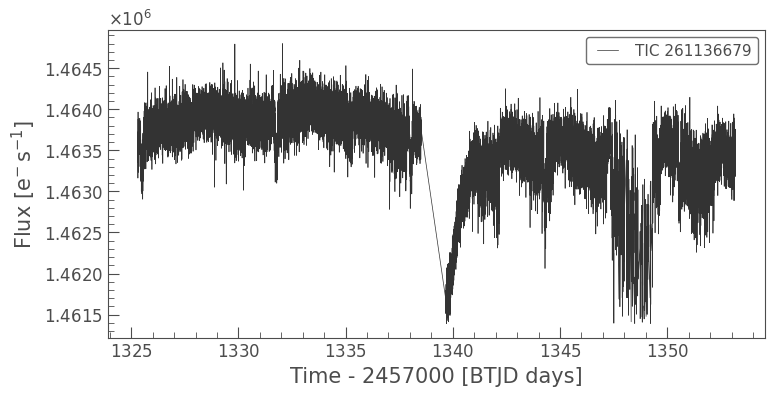

In [ ]:
# remocao de outliers
lc = lc.remove_outliers(sigma=5)
lc.plot()
plt.show()

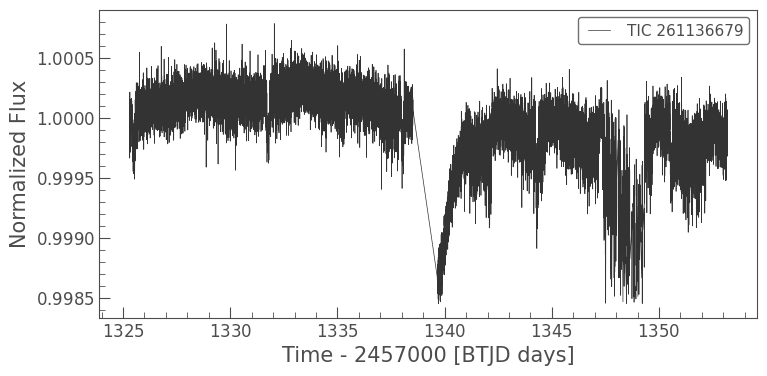

In [ ]:
lc = lc.normalize()
lc.plot()
plt.show()

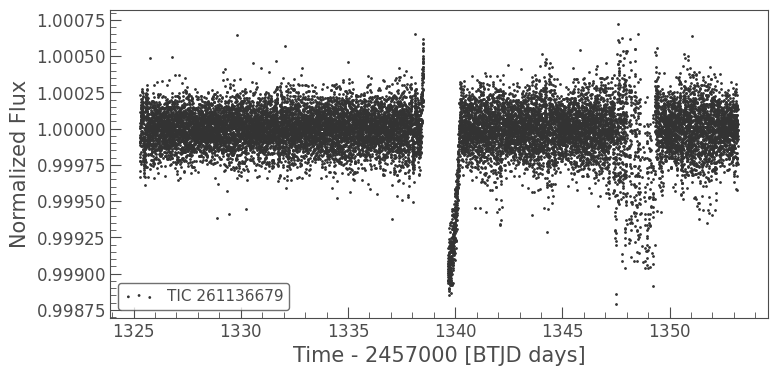

In [ ]:
flat_lc = lc.flatten(window_length=301, break_tolerance=None)
flat_lc.scatter()
plt.show()

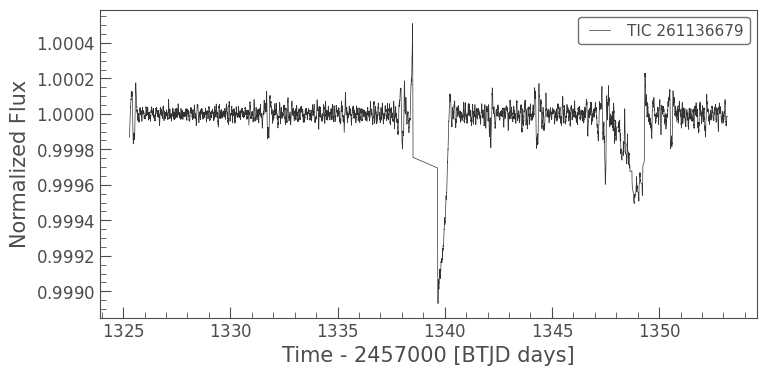

In [ ]:
flat_lc.flux = savgol_filter(flat_lc.flux, window_length=51, polyorder=2)
flat_lc.plot()
plt.show()

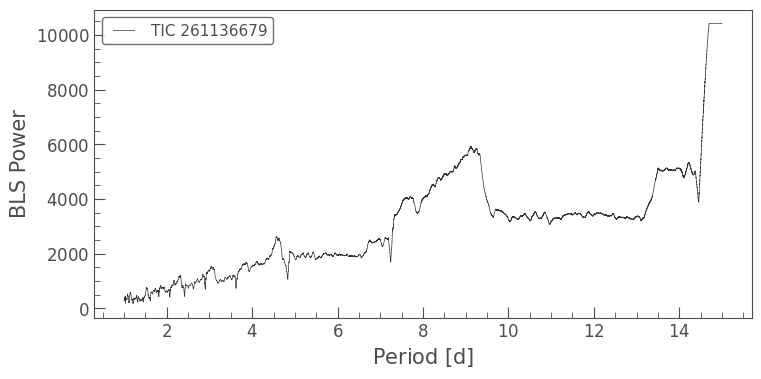

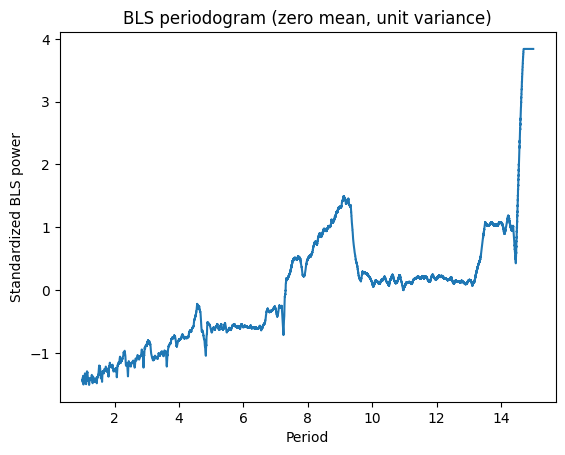

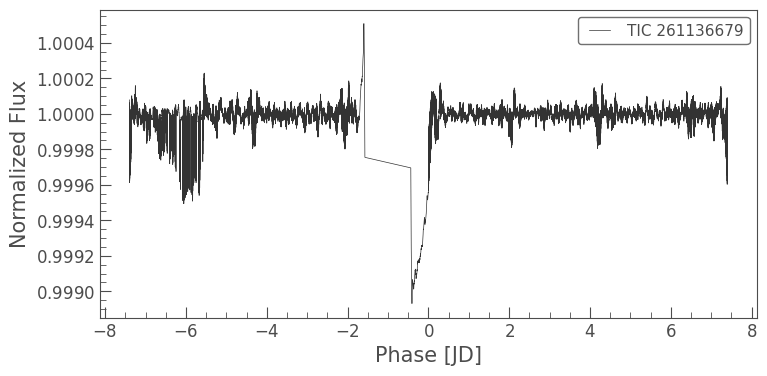

In [ ]:
periodogram = flat_lc.to_periodogram(method='bls', period=np.arange(1, 15, 0.001))
periodogram.plot()
plt.show()

power = periodogram.power
power_std = (power - np.mean(power)) / np.std(power)

# 3. plot
plt.plot(periodogram.period, power_std)
plt.xlabel('Period')
plt.ylabel('Standardized BLS power')
plt.title('BLS periodogram (zero mean, unit variance)')
plt.show()

best_period = periodogram.period_at_max_power
t0 = periodogram.transit_time_at_max_power.value
folded = flat_lc.fold(period=best_period)
folded.plot()
plt.show()

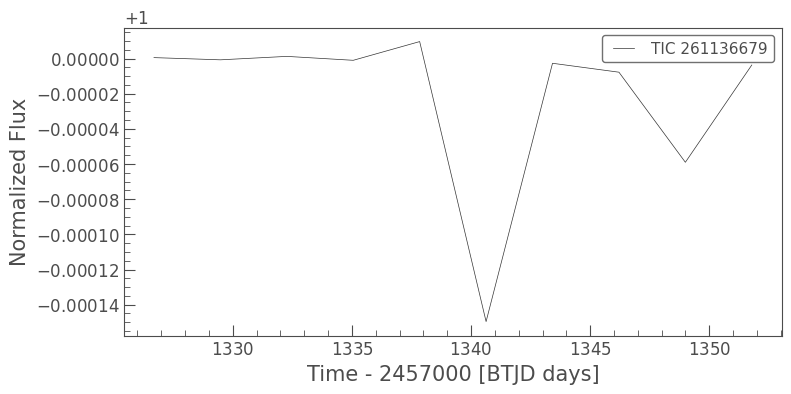

In [ ]:
binned = flat_lc.bin(bins=10)
binned.plot()
plt.show()

In [ ]:
lc_dobrada = flat_lc.fold(period=best_period, epoch_time=t0)

lc_dobrada.scatter(title=f"Trânsito Dobrado (Período: {best_period:.2f} d)", color='black', alpha=0.5)
plt.show()